<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/TQQQ_TLT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --upgrade yfinance
!pip install  --upgrade pandas_ta
!pip install ta pandas_ta

In [2]:
import yfinance as yf
print(yf.__version__)
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import time
import ta
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', None)
print("Libraries Installed!")

1.2.1
Libraries Installed!


In [3]:
# Download data
tickers = ["TQQQ", "TLT"]
data = yf.download(tickers, start="2024-01-01", interval="1d",auto_adjust=True)["Close"]

# Compute returns
returns = data.pct_change()

# Lookback window (3 months ~ 63 trading days)
window = 63

# Inspect dataframe
data.head()

[*********************100%***********************]  2 of 2 completed


Ticker,TLT,TQQQ
Date,,
2024-01-02,89.407341,23.497490
2024-01-03,89.780251,22.745649
2024-01-04,88.416084,22.364843
2024-01-05,87.570282,22.447840
2024-01-08,88.434273,23.800179


In [4]:

def compute_relative_strength(prices, method="raw"):
    roc = prices.pct_change(window) # 3-month return

    if method == "raw":
        rs = roc
    elif method == "vol_adj":
        vol = returns.rolling(window).std() * np.sqrt(window)
        rs = roc / vol
    else:
        raise ValueError("Method must be 'raw' or 'vol_adj'")

    return rs


    # Compute signals
rs_raw = compute_relative_strength(data, method="raw")
rs_vol = compute_relative_strength(data, method="vol_adj")



In [5]:
# Resample monthly (take last available signal each month)
rs_raw_m = rs_raw.resample("ME").last()

#print("Relative strengths are :",rs_raw_m )
rs_raw_m.tail(10)

Ticker,TLT,TQQQ
Date,,
2025-07-31,-0.017646,0.611824
2025-08-31,0.015069,0.280145
2025-09-30,0.021701,0.279501
2025-10-31,0.032804,0.335829
2025-11-30,0.053076,0.221847
2025-12-31,-0.013004,0.007106
2026-01-31,-0.032841,-0.103150
2026-02-28,0.017830,-0.046384
2026-03-31,-0.008619,-0.233824


In [6]:
# Resample monthly (take last available signal each month)
rs_vol_m = rs_vol.resample("ME").last()
#print("Volatility normalized Relative strengths are :",rs_vol_m )
rs_vol_m.tail(10)

Ticker,TLT,TQQQ
Date,,
2025-07-31,-0.291671,2.937019
2025-08-31,0.270172,1.553007
2025-09-30,0.404573,1.728528
2025-10-31,0.689163,1.603699
2025-11-30,1.132000,0.867900
2025-12-31,-0.313935,0.026318
2026-01-31,-0.816995,-0.424841
2026-02-28,0.423324,-0.209286
2026-03-31,-0.164704,-0.865862


In [7]:
def generate_signals(rs):
    # Create a Series filled with 'CASH' for rows that are all NaN
    signals = pd.Series("CASH", index=rs.index)

    # Identify rows that are not all NaN
    valid_rows = rs.notna().any(axis=1)

    # For valid rows, pick the strongest asset
    signals.loc[valid_rows] = rs[valid_rows].idxmax(axis=1)

    # Apply volatility filter: go to CASH if max < 0
    signals.loc[rs.max(axis=1) < 0] = "CASH"

    return signals

signals_raw = generate_signals(rs_raw_m)
signals_vol = generate_signals(rs_vol_m)

# Strategy returns
monthly_returns = returns.resample("ME").apply(lambda x: (1+x).prod() - 1)

monthly_returns


Ticker,TLT,TQQQ
Date,,
2024-01-31,-0.016783,0.093704
2024-02-29,-0.022522,0.146656
2024-03-31,0.007829,0.023561
2024-04-30,-0.064554,-0.143275
2024-05-31,0.028870,0.185628
2024-06-30,0.018171,0.185068
2024-07-31,0.036299,-0.075047
2024-08-31,0.021112,0.004833
2024-09-30,0.019994,0.059954


In [8]:
signals_vol.index[:-1]

signals_vol.loc['2025-11-30']

'TLT'

In [9]:
def backtest(signals, cap_tqqq=False):
    strat_rets = []
    for date in signals.index[:-1]:
        asset = signals.loc[date]
        next_ret = monthly_returns.loc[date]

        if asset == "CASH":
            strat_rets.append(0)
        elif asset == "TQQQ" and cap_tqqq:
            strat_rets.append(0.7 * next_ret["TQQQ"]) # 50% cap
        elif asset == "TQQQ":
            # Instead of 50% TQQQ + 50% cash
            strat_rets.append(0.5 * next_ret["TQQQ"] + 0.5 * next_ret["QQQ"])
        else:
            strat_rets.append(next_ret[asset])

    return pd.Series(strat_rets, index=signals.index[:-1])

# Backtests
bt_raw = backtest(signals_raw, cap_tqqq=True)
bt_vol = backtest(signals_vol, cap_tqqq=True)

# Equity curves
equity_raw = (1 + bt_raw).cumprod()
equity_vol = (1 + bt_vol).cumprod()

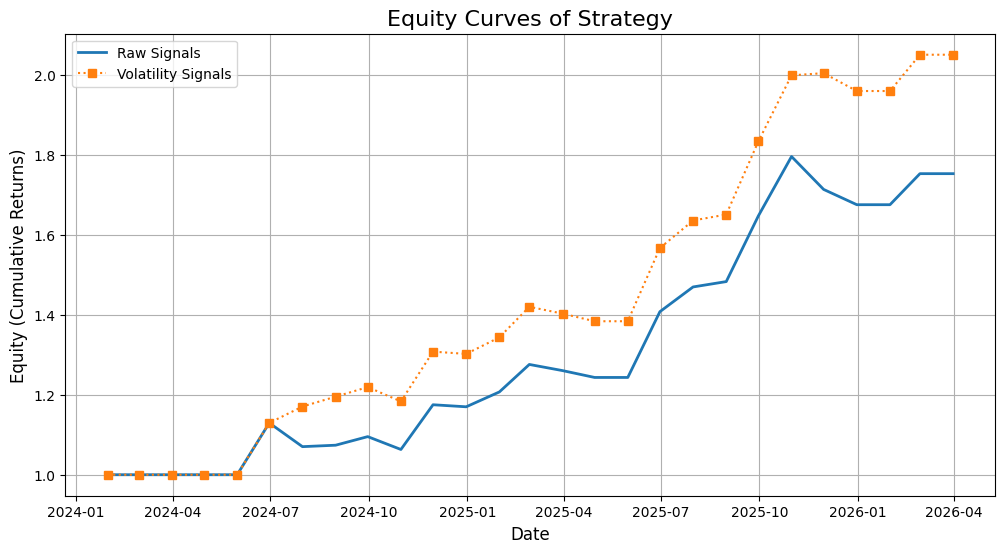

In [10]:

plt.figure(figsize=(12,6))

# Raw signals: solid line
plt.plot(equity_raw, label="Raw Signals", linewidth=2)

# Volatility signals: dotted line with square markers
plt.plot(
    equity_vol,
    label="Volatility Signals",
    linestyle=":",   # dotted line
    marker="s",     # square markers
    markersize=6,
    linewidth=1.5
)

plt.title("Equity Curves of Strategy", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Equity (Cumulative Returns)", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()



In [11]:


def evaluate_strategy(strategy_returns, periods_per_year=12, risk_free=0.0):
    """
    Evaluate a strategy's performance metrics.

    Parameters:
    - strategy_returns: pd.Series of returns (monthly or daily)
    - periods_per_year: 12 for monthly, 252 for daily
    - risk_free: annual risk-free rate (default 0)

    Returns:
    - pd.Series with key metrics
    """

    # Remove NaNs
    returns = strategy_returns.dropna()

    # Cumulative return
    cumulative = (1 + returns).prod() - 1

    # Annualized return
    ann_return = (1 + cumulative) ** (periods_per_year / len(returns)) - 1

    # Annualized volatility
    ann_vol = returns.std() * np.sqrt(periods_per_year)

    # Sharpe ratio
    sharpe = (ann_return - risk_free) / ann_vol if ann_vol != 0 else np.nan

    # Equity curve & drawdowns
    equity = (1 + returns).cumprod()
    drawdown = equity / equity.cummax() - 1
    max_dd = drawdown.min()

    # Calmar ratio
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    # Sortino ratio
    downside_std = returns[returns < 0].std() * np.sqrt(periods_per_year)
    sortino = (ann_return - risk_free) / downside_std if downside_std != 0 else np.nan

    # Win rate / hit ratio
    win_rate = (returns > 0).mean()

    metrics = {
        "Cumulative Return": cumulative,
        "Annualized Return": ann_return,
        "Annualized Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd,
        "Calmar Ratio": calmar,
        "Sortino Ratio": sortino,
        "Hit Ratio": win_rate
    }

    return pd.Series(metrics)

# Example usage
metrics_raw = evaluate_strategy(bt_raw)
metrics_vol = evaluate_strategy(bt_vol)

# Combine into one table
metrics_comparison = pd.DataFrame({
    "Raw RS": metrics_raw,
    "Volatility-Weighted RS": metrics_vol
})

metrics_comparison


,Raw RS,Volatility-Weighted RS
Cumulative Return,0.753039,1.050547
Annualized Return,0.283370,0.375970
Annualized Volatility,0.176955,0.162148
Sharpe Ratio,1.601368,2.318679
Max Drawdown,-0.067097,-0.029356
Calmar Ratio,4.223299,12.807303
Sortino Ratio,4.551544,11.217058
Hit Ratio,0.444444,0.518519


In [15]:
# Step 1: Fetch data
tickers = ["TQQQ", "TLT"]
monthly_prices = yf.download(tickers, start="2019-01-01", interval="1mo", auto_adjust=True)["Close"]
# Drop missing values
monthly_prices = monthly_prices.dropna()


# ====================== RELATIVE STRENGTH ======================
signals = pd.DataFrame(index=monthly_prices.index)
signals["RS_1M"] = monthly_prices["TQQQ"].pct_change(1) - monthly_prices["TLT"].pct_change(1)
signals["RS_3M"] = monthly_prices["TQQQ"].pct_change(3) - monthly_prices["TLT"].pct_change(3)
signals["RS_6M"] = monthly_prices["TQQQ"].pct_change(6) - monthly_prices["TLT"].pct_change(6)

# Smoothed versions (very useful)
signals["RS_1M_SMA3"] = signals["RS_1M"].rolling(3).mean()
signals["RS_3M_SMA3"] = signals["RS_3M"].rolling(3).mean()
signals["RS_6M_SMA3"] = signals["RS_6M"].rolling(3).mean()

# ====================== REGIME + DECISION LOGIC ======================
def get_regime_and_decision(df):
    signals = df.copy()

    # Regime based on 3-month smoothed RS (primary trend filter)
    signals["Regime"] = pd.NA
    signals.loc[signals["RS_3M_SMA3"] > 0, "Regime"] = "Risk-On (favor TQQQ)"
    signals.loc[signals["RS_3M_SMA3"] < 0, "Regime"] = "Risk-Off (favor TLT)"

    # Final Decision
    signals["Decision"] = "WAIT (no alignment)"
    signals["Regime"]   = "Neutral"
    signals["Strength"] = "Weak"
    signals["Position"] = 0   # 1 = TQQQ, -1 = TLT, 0 = Cash

    # Strong TQQQ signal
    signals.loc[(signals["RS_3M_SMA3"] > 0) & (signals["RS_1M_SMA3"] > 0) & (signals["RS_6M_SMA3"] > 0), ["Decision", "Position"]] = ["ENTER TQQQ ✅", 1]

    # Strong TLT signal
    signals.loc[(signals["RS_3M_SMA3"] < 0) & (signals["RS_1M_SMA3"] < 0) & (signals["RS_6M_SMA3"] < 0), ["Decision", "Position"]] = ["ENTER TLT ✅", -1]

    # Optional: Add confidence level
    signals["Strength"] = "Weak"
    signals.loc[(signals["RS_3M_SMA3"] > 0) & (signals["RS_1M_SMA3"] > 0.015), "Strength"] = "Strong"
    signals.loc[(signals["RS_3M_SMA3"] < 0) & (signals["RS_1M_SMA3"] < -0.015), "Strength"] = "Strong"

    # ====================== BACKTEST ======================
    # Calculate monthly returns for both assets
    monthly_returns = monthly_prices.pct_change()

    # Strategy returns: Use previous month's position for current month's return (no lookahead)
    signals["Strategy_Return"] = signals["Position"].shift(1) * monthly_returns["TQQQ"] + \
                             (signals["Position"].shift(1) == -1) * monthly_returns["TLT"] * (-1)   # when Position=-1, we are long TLT
    # Fill NaN with 0 (no position = 0% return)
    signals["Strategy_Return"] = signals["Strategy_Return"].fillna(0)

    # Cumulative equity curves
    signals["TQQQ_BuyHold"] = (1 + monthly_returns["TQQQ"]).cumprod()
    signals["Strategy_Equity"] = (1 + signals["Strategy_Return"]).cumprod()

    # ====================== PERFORMANCE SUMMARY ======================
    print("=== PERFORMANCE SUMMARY (since 2019) ===")
    print(f"Final TQQQ Buy & Hold     : {signals['TQQQ_BuyHold'].iloc[-1]:.2f}x")
    print(f"Final Strategy Equity     : {signals['Strategy_Equity'].iloc[-1]:.2f}x")
    print(f"Strategy vs TQQQ Outperformance: {((signals['Strategy_Equity'].iloc[-1] / signals['TQQQ_BuyHold'].iloc[-1]) - 1)*100:.1f}%")

    return signals

signals = get_regime_and_decision(signals)

# Drop rows with NaN in key columns
signals = signals.dropna(subset=["RS_1M", "RS_3M"])


# ====================== OUTPUT ======================
print("Last 12 Months - TQQQ vs TLT Rotation Signals")
display_cols = ["RS_1M_SMA3", "RS_3M_SMA3", "Regime", "Decision","Strength", "Position", "Strategy_Return"]


signals[display_cols].tail(12).round(4)

[*********************100%***********************]  2 of 2 completed

=== PERFORMANCE SUMMARY (since 2019) ===
Final TQQQ Buy & Hold     : 8.56x
Final Strategy Equity     : 1.73x
Strategy vs TQQQ Outperformance: -79.8%
Last 12 Months - TQQQ vs TLT Rotation Signals


,RS_1M_SMA3,RS_3M_SMA3,Regime,Decision,Strength,Position,Strategy_Return
Date,,,,,,,
2025-05-01,0.0196,-0.2314,Neutral,WAIT (no alignment),Weak,0,-0.2433
2025-06-01,0.1472,0.0354,Neutral,WAIT (no alignment),Strong,0,0.0000
2025-07-01,0.1813,0.3656,Neutral,ENTER TQQQ ✅,Strong,1,0.0000
2025-08-01,0.0831,0.4560,Neutral,ENTER TQQQ ✅,Strong,1,0.0130
2025-09-01,0.0704,0.3733,Neutral,ENTER TQQQ ✅,Strong,1,0.1571
2025-10-01,0.0833,0.2547,Neutral,ENTER TQQQ ✅,Strong,1,0.1299
2025-11-01,0.0563,0.2225,Neutral,ENTER TQQQ ✅,Strong,1,-0.0655
2025-12-01,0.0149,0.1591,Neutral,ENTER TQQQ ✅,Weak,1,-0.0334
2026-01-01,-0.0174,0.0503,Neutral,WAIT (no alignment),Weak,0,0.0259


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


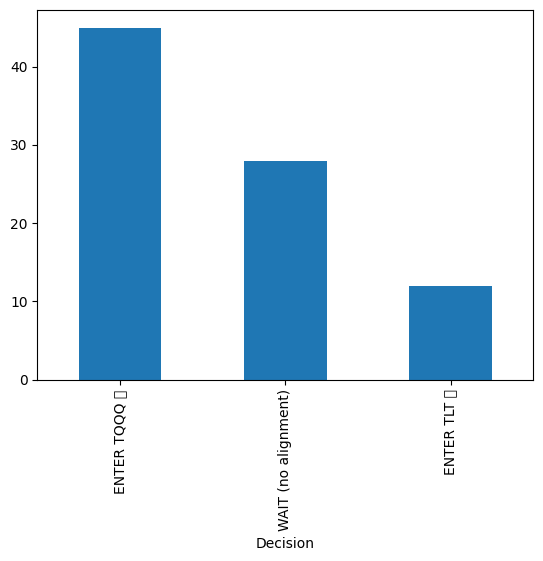

In [12]:
signals['Decision'].value_counts().plot(kind='bar')
plt.show()

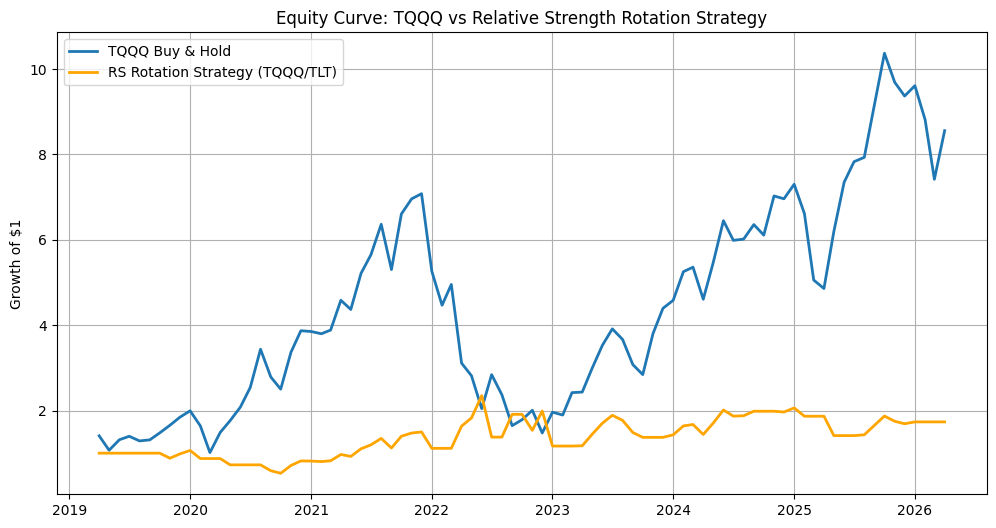

In [14]:
# ====================== PLOT EQUITY CURVES ======================
plt.figure(figsize=(12, 6))
plt.plot(signals.index, signals["TQQQ_BuyHold"], label="TQQQ Buy & Hold", linewidth=2)
plt.plot(signals.index, signals["Strategy_Equity"], label="RS Rotation Strategy (TQQQ/TLT)", linewidth=2, color='orange')
plt.title("Equity Curve: TQQQ vs Relative Strength Rotation Strategy")
plt.legend()
plt.grid(True)
plt.ylabel("Growth of $1")
plt.show()

In [25]:
# Step 1: Fetch data
tickers = ["TQQQ", "BIL"]
monthly_prices = yf.download(tickers, start="2019-01-01", interval="1mo", auto_adjust=True)["Close"]
# Drop missing values
monthly_prices = monthly_prices.dropna()


# ====================== RELATIVE STRENGTH ======================
signals = pd.DataFrame(index=monthly_prices.index)
signals["RS_1M"] = monthly_prices["TQQQ"].pct_change(1) - monthly_prices["BIL"].pct_change(1)
signals["RS_3M"] = monthly_prices["TQQQ"].pct_change(3) - monthly_prices["BIL"].pct_change(3)
signals["RS_6M"] = monthly_prices["TQQQ"].pct_change(6) - monthly_prices["BIL"].pct_change(6)

# Smoothed versions (very useful)
signals["RS_1M_SMA3"] = signals["RS_1M"].rolling(3).mean()
signals["RS_3M_SMA3"] = signals["RS_3M"].rolling(3).mean()
signals["RS_6M_SMA3"] = signals["RS_6M"].rolling(3).mean()

# ====================== REGIME + DECISION LOGIC ======================
def get_regime_and_decision(df):
    signals = df.copy()

    # Regime based on 3-month smoothed RS (primary trend filter)
    signals["Regime"] = pd.NA
    signals["Decision"] = "ENTER BIL ✅"
    #signals["Regime"]   = "Neutral"
    signals["Strength"] = "Weak"
    signals["Position"] = 0   # 1 = TQQQ, 0 = BIL
    signals.loc[signals["RS_3M_SMA3"] > 0, "Regime"] = "Risk-On (favor TQQQ)"
    signals.loc[signals["RS_3M_SMA3"] < 0, "Regime"] = "Risk-Off (favor BIL)"

    # Strong TQQQ signal
    signals.loc[(signals["RS_3M_SMA3"] > 0) & (signals["RS_1M_SMA3"] > 0) & (signals["RS_6M_SMA3"] > 0), ["Decision", "Position"]] = ["ENTER TQQQ ✅", 1]


    # Optional: Add confidence level
    signals.loc[(signals["RS_3M_SMA3"] > 0) & (signals["RS_1M_SMA3"] > 0.015), "Strength"] = "Strong"
    signals.loc[(signals["RS_3M_SMA3"] < 0) & (signals["RS_1M_SMA3"] < -0.015), "Strength"] = "Strong"

    # ====================== BACKTEST ======================
    # Calculate monthly returns for both assets
    monthly_returns = monthly_prices.pct_change()

    # Strategy returns: Use previous month's position for current month's return (no lookahead)
    signals["Strategy_Return"] = signals["Position"].shift(1) * monthly_returns["TQQQ"] + \
                             (signals["Position"].shift(1) == 0) * monthly_returns["BIL"]
    # Fill NaN with 0 (no position = 0% return)
    signals["Strategy_Return"] = signals["Strategy_Return"].fillna(0)

    # Cumulative equity curves

    signals["TQQQ_BuyHold"] = (1 + monthly_returns["TQQQ"]).cumprod()
    signals["Strategy_Equity"] = (1 + signals["Strategy_Return"]).cumprod()
    signals["BIL_Equity"] = (1 + monthly_returns["BIL"]).cumprod()

    # ====================== PERFORMANCE SUMMARY ======================
    print("=== PERFORMANCE SUMMARY (since 2019) ===")
    print("=== TQQQ vs BIL Rotation Strategy ===")
    print(f"Final TQQQ Buy & Hold     : {signals['TQQQ_BuyHold'].iloc[-1]:.2f}x")
    print(f"Final Strategy (TQQQ/BIL) : {signals['Strategy_Equity'].iloc[-1]:.2f}x")
    print(f"Final BIL                 : {signals['BIL_Equity'].iloc[-1]:.2f}x\n")
    print(f"Strategy vs TQQQ Outperformance: {((signals['Strategy_Equity'].iloc[-1] / signals['TQQQ_BuyHold'].iloc[-1]) - 1)*100:.1f}%")

    return signals

signals = get_regime_and_decision(signals)

# Drop rows with NaN in key columns
signals = signals.dropna(subset=["RS_1M", "RS_3M"])


# ====================== OUTPUT ======================
print("Last 12 Months - TQQQ vs BIL Rotation Signals")
display_cols = ["RS_1M_SMA3", "RS_3M_SMA3", "Regime", "Decision","Strength", "Position", "Strategy_Return"]


signals[display_cols].tail(12).round(4)

[*********************100%***********************]  2 of 2 completed

=== PERFORMANCE SUMMARY (since 2019) ===
=== TQQQ vs BIL Rotation Strategy ===
Final TQQQ Buy & Hold     : 8.56x
Final Strategy (TQQQ/BIL) : 4.52x
Final BIL                 : 1.20x

Strategy vs TQQQ Outperformance: -47.1%
Last 12 Months - TQQQ vs BIL Rotation Signals


,RS_1M_SMA3,RS_3M_SMA3,Regime,Decision,Strength,Position,Strategy_Return
Date,,,,,,,
2025-05-01,-0.0032,-0.2342,Risk-Off (favor BIL),ENTER BIL ✅,Weak,0,0.0037
2025-06-01,0.1372,0.0094,Risk-On (favor TQQQ),ENTER BIL ✅,Strong,0,0.0033
2025-07-01,0.1721,0.3234,Risk-On (favor TQQQ),ENTER BIL ✅,Strong,0,0.0037
2025-08-01,0.0847,0.4378,Risk-On (favor TQQQ),ENTER TQQQ ✅,Strong,1,0.0036
2025-09-01,0.0751,0.3698,Risk-On (favor TQQQ),ENTER TQQQ ✅,Strong,1,0.1571
2025-10-01,0.0965,0.2741,Risk-On (favor TQQQ),ENTER TQQQ ✅,Strong,1,0.1299
2025-11-01,0.0706,0.2549,Risk-On (favor TQQQ),ENTER TQQQ ✅,Strong,1,-0.0655
2025-12-01,0.0083,0.1801,Risk-On (favor TQQQ),ENTER TQQQ ✅,Weak,1,-0.0334
2026-01-01,-0.0285,0.0469,Risk-On (favor TQQQ),ENTER BIL ✅,Weak,0,0.0259


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


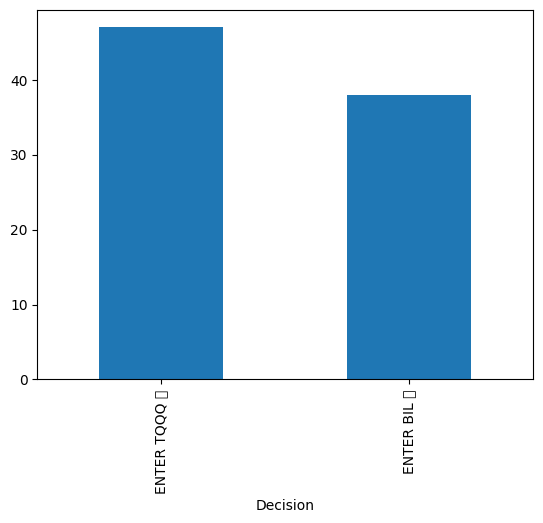

In [26]:
signals['Decision'].value_counts().plot(kind='bar')
plt.show()

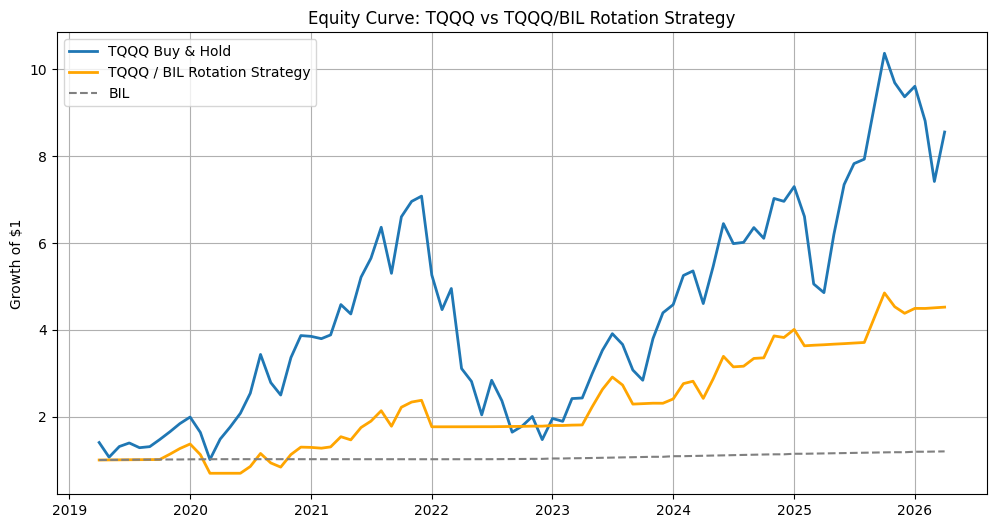

In [27]:
# ====================== PLOT EQUITY CURVES ======================
plt.figure(figsize=(12, 6))
plt.plot(signals.index, signals["TQQQ_BuyHold"], label="TQQQ Buy & Hold", linewidth=2)
plt.plot(signals.index, signals["Strategy_Equity"], label="TQQQ / BIL Rotation Strategy", linewidth=2, color='orange')
plt.plot(signals.index, signals["BIL_Equity"], label="BIL", linewidth=1.5, color='gray', linestyle='--')
plt.title("Equity Curve: TQQQ vs TQQQ/BIL Rotation Strategy")
plt.legend()
plt.grid(True)
plt.ylabel("Growth of $1")
plt.show()

[*********************100%***********************]  6 of 6 completed


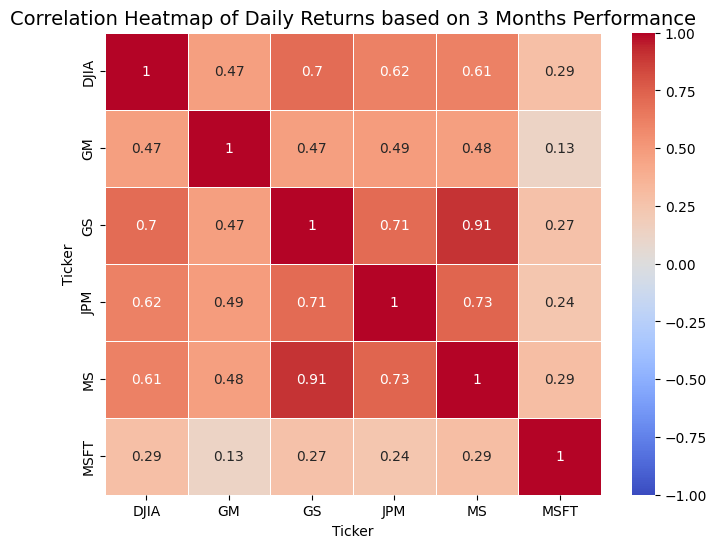

Ticker,DJIA,GM,GS,JPM,MS,MSFT
Ticker,,,,,,
DJIA,1.000000,0.472590,0.697684,0.616327,0.610215,0.288980
GM,0.472590,1.000000,0.472075,0.489453,0.476244,0.132714
GS,0.697684,0.472075,1.000000,0.705029,0.905840,0.271976
JPM,0.616327,0.489453,0.705029,1.000000,0.727804,0.238051
MS,0.610215,0.476244,0.905840,0.727804,1.000000,0.293410
MSFT,0.288980,0.132714,0.271976,0.238051,0.293410,1.000000


In [19]:

def get_correlation(tickers, period="3mo", interval="1d"):
    """
    Finds correlations.

    Parameters:
    -----------
    tickers : list
        All candidate tickers.
    period : str
        Data period for yfinance (default "3mo").
    interval : str
        Data interval (default "1d").

    Returns:
    --------
    corr_matrix : DataFrame
        Correlation matrix of daily returns.
    """
    # Step 1: Get prices
    data = yf.download(tickers, period=period, interval=interval,auto_adjust=True)["Close"]
    data = data.ffill()

    # Step 2: Convert to daily returns
    returns = data.pct_change().dropna()

    # Step 3: Correlation matrix
    corr_matrix = returns.corr()


     # Step 4: Plot heatmap
    plt.figure(figsize=(8,6))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5
    )
    plt.title("Correlation Heatmap of Daily Returns based on 3 Months Performance", fontsize=14)
    plt.show()

    return corr_matrix


# Example usage
#tickers = ['PLTR', 'NVDA', 'MSFT', 'HOOD', 'GM','AAPL','GE','JPM', 'QQQ']  # Replace with your list of tickers
tickers = ['GS', 'MS', 'MSFT', 'JPM', 'GM', 'DJIA']  # Replace with your list of tickers
ranked_picks = tickers

corr_matrix = get_correlation(tickers)


corr_matrix

import investpy

data = investpy.get_stock_historical_data(
    stock='Fidelity Bank',
    country='Nigeria',
    from_date='01/01/2023',
    to_date='03/10/2025'
)
print(data.tail())
